ESERCIZIO GUIDATO: PREDIZIONE SERIE TEMPORALI CON LSTM

Immagina di dover pianificare le scorte di magazzino, sapere cosa accade nell'intera settimana e venire, è una strategia vincente.

- Strategie per la predizione multi-step
- Analisi della stagionalità
- Valutazione dell'errore residuo

Perchè prevedere domani non ci basta più?
Nel mondo reale l'orrizonte temporale è tutto

Oltre il domani
Mano a mano che ci allontaniamo dal presente, le variabili impazziscono. passiamo da un modello che produce uno scalare ad uno che produce un vettore.

Cosè una serie temporale?
è una sequenza di osservazioni oridnate nel tempo.
L'ordine è fondamentale. Non puoi mescolare liberamente le righe come in un domanda di classificazione, perchè il valore di giovedi viene dopo quello di mercoledi.
Una previsione temporale prova a imparare una funzione del tipo:
passato -> futuro
Esistono previsioni single-step: prevedo un solo valore. esempio [100,110,95,130] -> 140, prevediamo un solo valor futuro
Esistono previsioni multi-step: [100,110,95,130] -> [140,125,118], prevediamo contemporaneamente più valori futuri

Finestra di input e orizzonte di previsione
Servono due parametri fondamentali
- La finestra di input, spesso chiamata lookback, stabilisce quanto passato viene mostrato al modello
- L'orizzonte, indicato spesso con H, stabilisce quanti valori futuri vogliamo prevedere
Esempio 
loobak=5, horizon=3
serie=10,12,14,13,15,17,18,20,...
input= [10,12,14,13,15], [12,14,13,15,17]
output=[17,18,20]      , [18,20,...]
Questa tecnica è chiamata sliding window

Architetture per l'Orizzonte
Stategie di emissione dell'otuput
- Vettore di Output: il layer finale 'Dense' viene configurato con un numero di neuroni pari all'orizzonte temporale desiderto, in questo caso sette (per una settimana). Invece di usare la predizone lunedi predizione martedi, ecc, chiediamo alla rete di emettere lunedi martedi mercoledi tutti insieme. La rete impara a mappare il passato sull'intero blocco di futuro. La loss non guarda un singolo punto ma l'intera forma della predetta.
Il layer finale sarà keras.layers.Dense(7)
- Strategia Diretta: il modello impare a mappare la finestra di input direttamente sull'intera sequenza target in un singolo passaggio
- Loss Multi-output: la funzione di costo viene calcolata come media dell'errore su tutti i passi temporali della predizione
- Auto-regressività: concetto di utilizzare le predizioni precedenti come input per quelle successive, sebbene più incline all'accumulo di errori.

Preparazione dei dati multi-step

Finestra Target
A differenza del caso single-step, la nostra etichetta o label non è più un singolo numero ma un segmeto di lunghezza 'H'
Shape dei Tensori
I dati devono essere formattati correttamente per gestire la dimensione dell'orizzonte nel calcolo del gradiente
Trade-Off di Complessità. Dobbiamo gestire il batch e l'orizzonte contemporaneamente
Aumentare l'orizzonte aumenta la varianza della predizione, poichè l'incertezza cresce man mano che ci si allontana dal presente.

Una LSTM riceve normalmente un tensore tridimensionale
campioni x passi temporali x caratteristiche 
in forma keras:
(batch_size, timesteps, features)
Esempio:
32 campioni per batch
30 giorni di passato
1 caratteristica: consumo
la shape sarà:
(32,30,1) X.shape=(numero_campioni,30,1)
con una previsione di 7 giorni l'output sarà
(32,7) y.shape=(numero_campioni,7)
Se abbiamo più caratteristiche e non solo 1 come in precedenza
consumo, prezzo, promozione, ecc
supponiamo che sono 6 le caratteristiche
X.shape=(numero_campioni,30,6)
y.shape=(numero_campioni,7) se vogliamo prevedere solo il consumo pur avendo più caratteristiche

L'approccio Vector Output
Mappatura globale della sequenza
L'uso di un output vettoriale (invece di un singolo numero) permette alla rete di catturare le correlazioni tra i giorni consecutivi della settimana prevista.
Questo approccio evita il decadimento tipico dei modeli ricorsivi che riutilizzano l'output come input.

Ma c'è un nemico che può confondere anche la migliore rete: i cicli ripetitivi

Analisi della Stagionalità
I ritmi nascosti dei dati
Le serie temporali sono spesso influenzate da cicli ripetitivi, come la variaza giornaliera, settimanale, o annuale. Ignorare questi pattern significa perdere informazione cruciale
Esploriamo come identificare queste componenti per aiutare il modello a non confondere un trend di lungo periodo con un semplice picco stagionale.

Componenti della Serie
Decomposizione del segnale
- Trend (o tendenza): è la direzione di fondo dei dati nel lungo periodo, indipendentemente dalle fluttuazioni locali. E' una crescita o  una diminuzione nel lungo periodo.
- Componente Stagionale: fluttuazioni periodiche che si ripetono con una frequenza fissa e nota. La frequenza dipende dal dato, per dati giornalieri potremmo avere: stagionalità settimanale, stagionalità annuale, più stagionalità contemporanee
- Componente Residua: ciò che rimane dopo aver rimosso trend e stagionalità, ovvero il rumore o l'informazione non strutturata. Può contenere: rumore casuale, anomalie, eventi esterni, pattern che il modello non ha ancora imparato. Quindi non è corretto considerarlo automaticamente solo rumore
- Differenziazione: tecnica per rendere la serie stazionaria rimuovendo il trend prima dell'addestramento.
Possiamo usare la differenziazione per appiattire il trend, rendendo la serie stazionaria.

valore osservato = tendenza (trend) + stagionalità + altri effetti + rumore
Non tutte le serie contengono tutte queste componenti

Esiste un trucco matematico per far comprendere il tempo alla rete senza parole.

Encoding ciclico: se diciamo alla rete che i mesi sono da 1 e 12, la rete potrebbe pensare che dicembre e gennaio sono lontani (in realtà sono vicini), usando seno e coseno portiamo il tempo su un cerchio, dicembre e gennaio tornano ad essere vicini nello spazio matematico.

L'importanza della Stazionarietà
Stabilizzare la distribuzione
Una rete neurale è felice quando la media e la varianza non cambiano troppo durante il training, cioè quando le sue proprietà statistiche non cambiano troppo nel tempo.
- media relativamente stabile - varianza relativamente stabile - struttura delle dipendenze abbastanza stabile

Fornendo alla LSTM dati ciclici non la costringiamo ad indovinare in che mese ci troviamo, lo diciamo noi. Questo riduce le epoche di addetramento.
Una serie non stazionaria ha media e varianza che cambiano nel tempo, rendendo difficile per la rete neurale trovare un ottimo stabile.
Rimuovere la stagionalità permette alla LSTM di concentrarsi sulla previsione delle anomalie e dei cambiamenti improvvisi.
Una LSTM può teoricamente imparare trend e stagionalità. Tuttavia, trasformazioni che stabilizzano scale, media e varianza possono rendere l'addestramento più semplice e stabile.
Quindi, rimuovere la stagionalità può essere buono ma non è l'unica strada possibile
Hai 3 possibilità:
- lasciare la stagionalità nella serie: la LSTM prova a impararla direttamente, è ragionevole se hai molti dati, ciclo stabile, la finestra contiene almeno un o più cicli completi. Per stagionalità settimanale lookback almeno=7 o ancora meglio lookback=14,21,28
- inserire feature stagionali: aggiungi giorno della settimana (mese, festivo, fine mese, chiusura aziendale). Questo aiuta la rete
- rimuovere la stagionalità e prevedere il residue: scomponi la serie in serie=stagionalità+residuo. Prevedi il residuo e poi aggiungi nuovamente la stagionalità. E' più complesso, ma può essere utile se la stagionalità è molto forte e stabile

Ora che il modello ha compreso la settimana, come valutiamo il modello?

Valutazione dell'Errore Residuo
Diagnostica del Modello
Una volta addestrato il modello, dobbiamo chiederci: cosa ha lasciato per strada? L'analisi dei residui ci dice se il modello ha estratto tutta l'informazione utile.
L'analisi della distribuzione degli errori può rivelare problemi, bias o sottostima sistematica in determinate condizioni.
L'analisi dei residue è come guardare i resti di una cena, per capire cosa gli ospiti hanno gradito. L'analisi dei residui ci dice esattamente cosa è rimasto fuori dalla comprensione di un modello.

Analisi dell'Errore
Metriche di precisione
- Residuo: la differenza tra il valore reale osservato e quello predetto dal modello per ogni passo dell orizzonte
- Distribuzione normale: un modello perfetto dovrebbe avere residui distribuiti come rumore bianco con media zero.
- Autocorrelazione dei Residui: se gli errori sono correlati tra loro, il modello ha ignorato un pattern temporale predicibile
-Eteroschedasticità: quando l'ampiezza dell'errore cambia nel tempo, indicando che il modello fatica in certi regimi di varianza.

e come cambia l'errore man mano che guardiamo più lontano nel tempo?

In una previsione multi-step di solito l'errore non è democratico. La previsione per domani è precisa, quella per dopo domani un pò meno, quella per il giorno dopo ancora meno precisa e così via. Questo effetto di chiama degradazione dell'errore. E' necessario quantificare questo scollamento. Un'azienda deve sapere che può fidarsi dei primi due giorni, ma deve prendere con le pinze gli ultim 3.
Metriche per Multi-step
- MSE per Orizzonte: calcolare l'errore separatamente per il giorno 1, il giorno 2, fino al giorno 7, per vedere dove la rete perde precisione.
Analisi Outliers
Identificare i giorni in cui la predizione fallisce drasticamente può indicare eventi esterni non catturati dai dati storici
Riepilogo Errore Quadratico
L'errore Quadratico Medio rimane la metrica di riferimento per penalizzare maggiormente gli errori di grande entità

Ma come distinguiamo il rumore dal segnale dimenticato?
usiamo il coefficiente erre quadro, con l'analisi dell'auto correlazione

Oltre il valore puntuale
Intervalli di confidenza
Poichè la predizione a 7 giorni è incerta, è buona pratica calcolare la deviazione standard dei residui per fornire un range di errore.
Residual = real - pred.
Un residuo che mostra pattern visibili suggerisce che la finestra di input potrebbe essere troppo corta per catturare la memoria necessaria.
Se l'errore di oggi è simile a quello di ieri, la rete ha fallito nel catturare la dinamica temporale.

Normalizzazione dei dati
per una LSTM è un passaggio fondamentale

Separazione traing, validation, test
non devi fare una separazione casuale
corretto potrebbe essere:
2022-2024 -> training
2025 -> validation
2026 -> test
In una serie il test deve rappresentare il futuro



[INFO] Addestramento in corso con backend PyTorch...


c:\EPICODE\Epicode_Python_AI_MachineLearning\.venv\Lib\site-packages\keras\src\backend\torch\rnn.py:656: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  outputs, h_n, c_n = torch._VF.lstm(


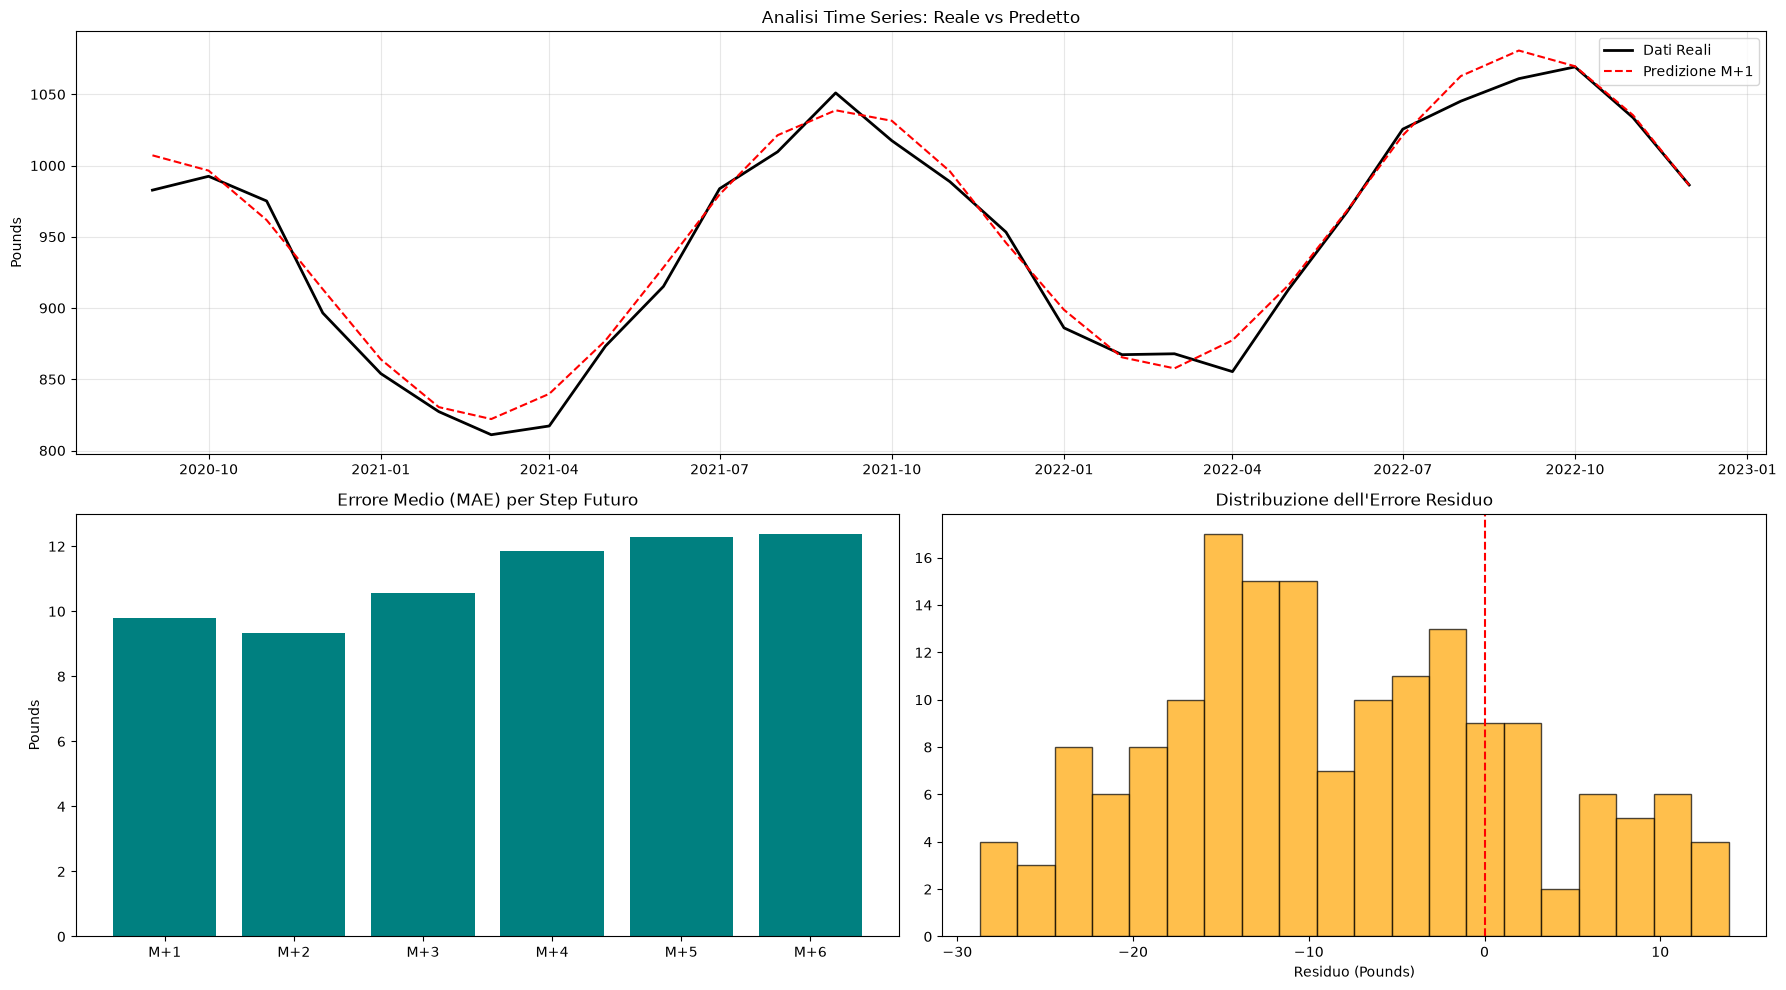

[LOG] Errore medio al primo mese (M+1): 9.78 Pounds


In [1]:
import os

# =================================================================
# 1. CONFIGURAZIONE AMBIENTE (Keras 3 Multi-Backend)
# =================================================================

# Impostiamo il backend su 'torch'. In Keras 3, questa variabile deve essere 
# definita PRIMA di importare keras per istruire il framework a usare 
# PyTorch come motore per il calcolo dei gradienti e dei tensori.
os.environ["KERAS_BACKEND"] = "torch"

import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Fissiamo i semi (seeds) per rendere l'esperimento riproducibile.
# Questo influenza l'inizializzazione dei pesi della rete e la generazione del rumore.
keras.utils.set_random_seed(42)

# =================================================================
# 2. GENERAZIONE DATASET SINTETICO
# =================================================================

# Creiamo un indice temporale mensile per 13 anni (156 mesi).
time_index = pd.date_range(start='2010-01-01', periods=156, freq='MS')

# Definiamo le componenti della serie storica: y(t) = Trend + Seasonality + Noise
# Trend: Una crescita lineare nel tempo (da 500 a 1000 pounds).
trend = np.linspace(500, 1000, 156) 

# Stagionalità: Una funzione seno per simulare il ciclo annuale naturale.
# 2*pi*n / 12 assicura che il ciclo si completi esattamente ogni 12 mesi.
seasonality = 100 * np.sin(2 * np.pi * np.arange(156) / 12) 

# Rumore: Fluttuazioni casuali (distribuzione normale) per simulare l'incertezza reale.
noise = np.random.normal(0, 10, 156) 

# Assembliamo il DataFrame finale di Pandas.
df = pd.DataFrame({'Production': trend + seasonality + noise}, index=time_index)
df.index.name = 'Month'

# =================================================================
# 3. ENCODING CICLICO DEL TEMPO
# =================================================================

# Problema: Se usiamo i mesi (1-12), il modello vede Dicembre (12) e Gennaio (1) 
# come numericamente distanti, mentre sono temporalmente vicini.
# Soluzione: Mappiamo il tempo su un cerchio unitario usando seno e coseno.
month_series = df.index.month
df['sin_month'] = np.sin(2 * np.pi * month_series / 12)
df['cos_month'] = np.cos(2 * np.pi * month_series / 12)

# 

# =================================================================
# 4. NORMALIZZAZIONE (Scaling)
# =================================================================

# Le LSTM sono sensibili alla scala dei dati. Usiamo MinMaxScaler per portare 
# tutto nell'intervallo [0, 1]. Questo aiuta la funzione di attivazione tanh 
# all'interno della LSTM a lavorare nella sua zona di massima pendenza (gradiente).
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Production', 'sin_month', 'cos_month']].values)

# =================================================================
# 5. FINESTRATURA (Windowing) PER PREDIZIONE MULTI-STEP
# =================================================================

def create_multistep_window(data, n_input, n_out):
    """
    Trasforma la serie piatta in un problema di apprendimento supervisionato.
    n_input: Quanti mesi passati guardiamo (Look-back window).
    n_out: Quanti mesi futuri vogliamo prevedere (Forecast horizon).
    """
    X, y = [], []
    for i in range(len(data)):
        end_ix = i + n_input
        out_end_ix = end_ix + n_out
        # Ci fermiamo quando non abbiamo abbastanza dati per completare l'orizzonte futuro.
        if out_end_ix > len(data): break
        
        # X: Matrice con (Mesi, Features). Features sono Production, Sin e Cos.
        X.append(data[i:end_ix, :])
        # y: Vettore target con solo la Produzione per i passi successivi.
        y.append(data[end_ix:out_end_ix, 0])
    return np.array(X), np.array(y)

# 

# Guardiamo 12 mesi per prevederne 6 contemporaneamente.
N_INPUT, N_OUT = 12, 6
X, y = create_multistep_window(scaled_data, N_INPUT, N_OUT)

# Dividiamo i dati: 80% per l'addestramento, 20% per il test finale (split cronologico).
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# =================================================================
# 6. ARCHITETTURA DEL MODELLO LSTM
# =================================================================

model = keras.Sequential([
    # Input: Riceve sequenze di 12 passi temporali con 3 variabili ciascuno.
    keras.layers.Input(shape=(N_INPUT, 3)),
    
    # LSTM: 128 neuroni ricorrenti. return_sequences=False perché vogliamo 
    # un unico output consolidato per alimentare lo strato denso finale.
    keras.layers.LSTM(128, activation='tanh', return_sequences=False),
    
    # Dropout: Spegne casualmente il 20% delle connessioni per evitare l'overfitting.
    keras.layers.Dropout(0.2),
    
    # Dense: Uno strato finale con N_OUT neuroni (6). Ogni neurone predice un mese futuro.
    keras.layers.Dense(N_OUT)
])

# AdamW: Variante moderna dell'ottimizzatore Adam con gestione migliorata del Weight Decay.
model.compile(optimizer='adamw', loss='mse', metrics=['mae'])

# =================================================================
# 7. ADDESTRAMENTO
# =================================================================

print("[INFO] Addestramento in corso con backend PyTorch...")
# epochs=150: Il modello vedrà i dati 150 volte. 
# batch_size=16: I pesi vengono aggiornati ogni 16 esempi.
model.fit(X_train, y_train, epochs=150, batch_size=16, 
          validation_data=(X_test, y_test), verbose=0)

# =================================================================
# 8. VALUTAZIONE E INVERSIONE DELLO SCALING
# =================================================================

# Generiamo le predizioni sui dati di test.
predictions = model.predict(X_test, verbose=0)

# Dobbiamo riportare i dati dalla scala [0,1] all'unità originale (Pounds).
# Creiamo uno scaler "fittizio" che conosce solo i parametri della colonna Production.
production_scaler = MinMaxScaler()
production_scaler.min_, production_scaler.scale_ = scaler.min_[0], scaler.scale_[0]

y_test_real = production_scaler.inverse_transform(y_test)
y_preds_real = production_scaler.inverse_transform(predictions)

# Residui: Differenza tra il valore reale e quello predetto (Errore).
residuals = y_test_real - y_preds_real

# =================================================================
# 9. VISUALIZZAZIONE RISULTATI (Plotting)
# =================================================================

plt.figure(figsize=(18, 10))

# SUBPLOT 1: Confronto Reale vs Predetto sul primo mese dell'orizzonte (M+1).
plt.subplot(2, 1, 1)
plt.plot(df.index[-len(y_test_real):], y_test_real[:, 0], label='Dati Reali', color='black', linewidth=2)
plt.plot(df.index[-len(y_preds_real):], y_preds_real[:, 0], label='Predizione M+1', color='red', linestyle='--')
plt.title("Analisi Time Series: Reale vs Predetto")
plt.ylabel("Pounds")
plt.legend()
plt.grid(True, alpha=0.3)

# SUBPLOT 2: Degradazione dell'errore. 
# Più ci allontaniamo nel tempo (da M+1 a M+6), più l'errore tende a salire.
plt.subplot(2, 2, 3)
mae_per_step = np.mean(np.abs(residuals), axis=0)
plt.bar([f"M+{i+1}" for i in range(N_OUT)], mae_per_step, color='teal')
plt.title("Errore Medio (MAE) per Step Futuro")
plt.ylabel("Pounds")

# 

# SUBPLOT 3: Distribuzione dei Residui. 
# Se l'errore segue una campana di Gauss centrata sullo zero, il modello non ha bias sistematici.
plt.subplot(2, 2, 4)
plt.hist(residuals.flatten(), bins=20, color='orange', edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribuzione dell'Errore Residuo")
plt.xlabel("Residuo (Pounds)")

plt.tight_layout()
plt.show()

print(f"[LOG] Errore medio al primo mese (M+1): {mae_per_step[0]:.2f} Pounds")